# Modelado 

Predicción de cancelaciones de reservas (`is_canceled`) — clasificación binaria.

## 0 · Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, RandomizedSearchCV)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)

RANDOM_STATE = 42   # el MISMO que usará A en el split
pd.set_option("display.max_columns", None)

## 1 · Preprocesado


In [3]:
# Datos definitivos (preprocesado de Nil — feature/preprocessing)
X_train = pd.read_csv("../data_sample/X_train.csv")
X_test = pd.read_csv("../data_sample/X_test.csv")
y_train = pd.read_csv("../data_sample/y_train.csv").squeeze()
y_test = pd.read_csv("../data_sample/y_test.csv").squeeze()

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Balance train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

X_train: (71049, 98) | X_test: (23878, 98)
Balance train: 0.275 | test: 0.37


### 1.1 · Verificación anti-fuga

In [4]:
prohibidas = ["reservation_status", "reservation_status_date"]
fugas = [c for c in prohibidas if c in X_train.columns]
assert not fugas, f"¡FUGA! Elimina estas columnas: {fugas}"
assert X_train.isna().sum().sum() == 0, "Quedan NaN en X_train"
print("OK — sin columnas de fuga y sin NaN")

OK — sin columnas de fuga y sin NaN


## 2 · Métrica de evaluación

**F1** como métrica principal: las clases están desbalanceadas (~37 % de cancelaciones),
así que la accuracy premiaría a un modelo que casi siempre dijera "no cancela". Al hotel le
importan los dos errores (no detectar una cancelación real, y molestar a un cliente que sí
vendrá con confirmaciones innecesarias), por lo que F1, que equilibra precision y recall,
es la métrica más honesta. Reportamos recall como secundaria por su valor operativo.

## 3 · Modelo baseline

In [5]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
pred = dummy.predict(X_test)

print("Accuracy baseline:", round(accuracy_score(y_test, pred), 3))
print("F1 baseline:      ", round(f1_score(y_test, pred), 3))
# Se espera F1 ~ 0: el baseline no acierta ninguna cancelación. Cualquier modelo real debe superarlo.

Accuracy baseline: 0.63
F1 baseline:       0.0


## 4 · Comparativa de modelos (validación cruzada)

Varios algoritmos con parámetros por defecto, comparados con CV estratificada **solo sobre train**.
SVM se omite a propósito: con ~120 k filas sería demasiado lento.

In [6]:
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "DecisionTree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest":       RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting":   GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN":                KNeighborsClassifier(n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

filas = []
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
    filas.append({"modelo": nombre, "f1_medio": scores.mean(), "std": scores.std()})
    print(f"{nombre:20s} F1 = {scores.mean():.3f} (+/- {scores.std():.3f})")

tabla = pd.DataFrame(filas).sort_values("f1_medio", ascending=False).reset_index(drop=True)
tabla

LogisticRegression   F1 = 0.561 (+/- 0.006)
DecisionTree         F1 = 0.615 (+/- 0.006)
RandomForest         F1 = 0.678 (+/- 0.005)
GradientBoosting     F1 = 0.627 (+/- 0.007)
KNN                  F1 = 0.595 (+/- 0.004)


,modelo,f1_medio,std
0,RandomForest,0.677992,0.005483
1,GradientBoosting,0.626570,0.006567
2,DecisionTree,0.615004,0.006362
3,KNN,0.594663,0.004475
4,LogisticRegression,0.561318,0.006026


### 4.1 · Gráfico de la comparativa

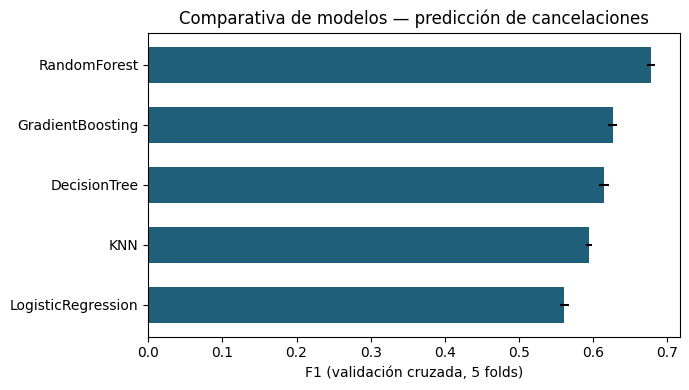

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(tabla["modelo"], tabla["f1_medio"], xerr=tabla["std"], color="#1f5f7a", height=0.6)
ax.invert_yaxis()
ax.set_xlabel("F1 (validación cruzada, 5 folds)")
ax.set_title("Comparativa de modelos — predicción de cancelaciones")
plt.tight_layout()
os.makedirs("../img", exist_ok=True)
plt.savefig("../img/comparativa_modelos.png", dpi=150)
plt.show()

### 4.2 · Variante con balanceo de clases

Dado que se detectó una diferencia en la proporción de clases entre train (27.5%) y test (37%)
tras la eliminación de duplicados, se prueba una variante de RandomForest con `class_weight="balanced"`
para comprobar si mejora la detección de la clase minoritaria (cancelaciones).

In [14]:
# Variante con balanceo de clases, dado el desbalance train/test detectado
rf_balanced = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, class_weight="balanced")
scores_balanced = cross_val_score(rf_balanced, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
print("F1 con class_weight='balanced':", round(scores_balanced.mean(), 3))

F1 con class_weight='balanced': 0.678


**Conclusión:** el balanceo de clases (`class_weight="balanced"`) no mejora el F1 (0.678 vs ~0.68 del RandomForest sin balancear). Se descarta esta variante y se continúa la optimización con el RandomForest estándar.

## 5 · Optimización de hiperparámetros

`RandomizedSearchCV` sobre el mejor modelo de la comparativa.

In [8]:
param_dist = {
    "n_estimators":      [100, 200, 300, 400],
    "max_depth":         [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2"],
}

busqueda = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=25, scoring="f1", cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1,
)
busqueda.fit(X_train, y_train)   # SOLO train

print("Mejores hiperparámetros:", busqueda.best_params_)
print("Mejor F1 en CV:        ", round(busqueda.best_score_, 3))

modelo_final = busqueda.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Mejores hiperparámetros: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Mejor F1 en CV:         0.682


## 6 · Evaluación final contra test

Primera y **única** vez que tocamos el test. Este número es el rendimiento esperado en producción.

In [9]:
y_pred  = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

print("Accuracy: ", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall:   ", round(recall_score(y_test, y_pred), 3))
print("F1:       ", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:  ", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=["No cancela", "Cancela"]))

# ⚠ Si accuracy o AUC salen > 0.97, revisar fuga de datos.

Accuracy:  0.887
Precision: 0.891
Recall:    0.791
F1:        0.838
ROC-AUC:   0.954

              precision    recall  f1-score   support

  No cancela       0.88      0.94      0.91     15033
     Cancela       0.89      0.79      0.84      8845

    accuracy                           0.89     23878
   macro avg       0.89      0.87      0.88     23878
weighted avg       0.89      0.89      0.89     23878



### 6.1 · Matriz de confusión

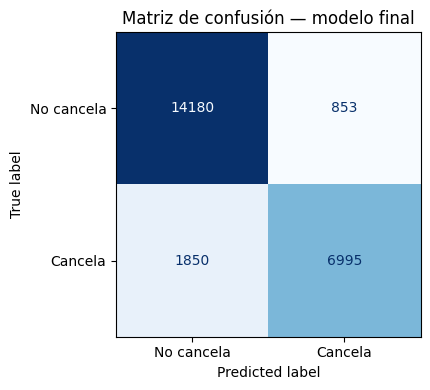

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    modelo_final, X_test, y_test, cmap="Blues", ax=ax, colorbar=False,
    display_labels=["No cancela", "Cancela"])
ax.set_title("Matriz de confusión — modelo final")
plt.tight_layout()
plt.savefig("../img/matriz_confusion.png", dpi=150)
plt.show()

### 6.2 · Curva ROC

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


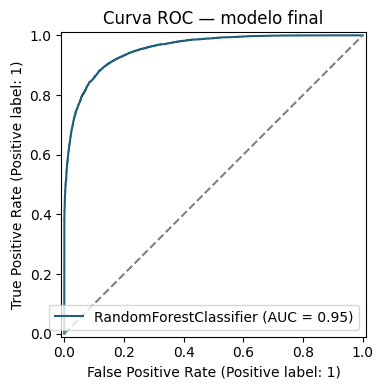

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_estimator(modelo_final, X_test, y_test, ax=ax, color="#1f5f7a")
ax.plot([0, 1], [0, 1], "--", color="gray")
ax.set_title("Curva ROC — modelo final")
plt.tight_layout()
plt.savefig("../img/curva_roc.png", dpi=150)
plt.show()

## 7 · Interpretabilidad — variables más importantes

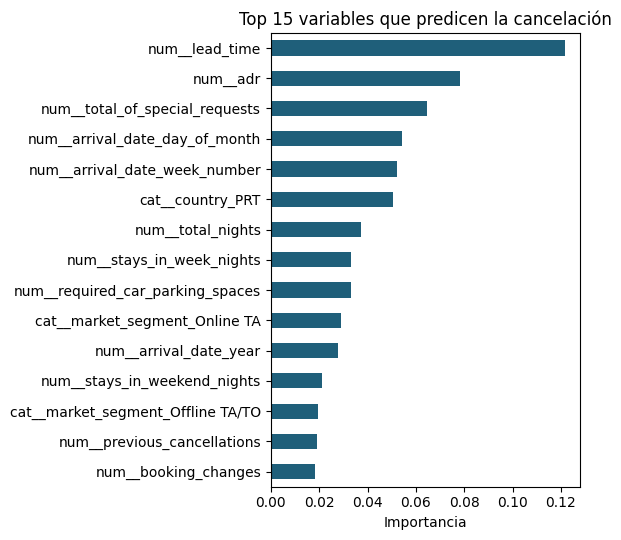

In [12]:
importancias = pd.Series(
    modelo_final.feature_importances_, index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 5.5))
importancias.tail(15).plot.barh(ax=ax, color="#1f5f7a")
ax.set_title("Top 15 variables que predicen la cancelación")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.savefig("../img/feature_importance.png", dpi=150)
plt.show()

## 8 · Guardar el modelo (requisito de entrega)

In [13]:
os.makedirs("../models", exist_ok=True)
joblib.dump(modelo_final, "../models/modelo_cancelaciones.joblib", compress=3)

print("Modelo guardado en src/models/modelo_cancelaciones.joblib")

Modelo guardado en src/models/modelo_cancelaciones.joblib


## 9 · Conclusiones

- F1 final obtenido: **0.838** (frente a baseline ~0).
- El modelo detecta el **79.1 %** de las cancelaciones reales (recall).
- Impacto de negocio: permite reasignar / reconfirmar las reservas de riesgo.
- Limitaciones: datos de dos hoteles concretos y de 2015-2017; puede no generalizar. 
  Además, se detectó una diferencia en el balance de clases entre train (27.5%) y 
  test (37%) tras la eliminación de duplicados en el preprocesado, lo cual pudo 
  influir ligeramente en el aprendizaje del modelo.
- Próximos pasos: ajustar el umbral para priorizar recall, reequilibrado de clases (SMOTE), más datos.

Con un recall del 79 % y precisión del 89 %, el modelo permite al hotel anticipar la 
mayoría de cancelaciones con pocas falsas alarmas, lo que sustenta decisiones de 
overbooking controlado y campañas de reconfirmación dirigidas a las reservas de mayor riesgo.